# Fine-Tuning NLLB-200 for Gĩkũyũ: Statistical Analysis

Companion analysis for the fine-tuning study that follows the Gĩkũyũ MT benchmark.
This notebook evaluates whether fine-tuning the NLLB-200 family on the Gĩkũyũ
Agricultural Corpus (GAC v1.1) yields statistically reliable improvements over the
corresponding pre-trained baselines, in both translation directions.

**Research questions**

1. **RQ1** Does fine-tuning on 1,835 in-domain pairs significantly improve translation
   quality over the pre-trained NLLB-200 baselines?
2. **RQ2** Does the within-family scaling advantage (600M → 3.3B) observed in the
   benchmark persist after fine-tuning, or does in-domain adaptation compress it?
3. **RQ3** Do the distilled and dense 1.3B checkpoints respond differently to fine-tuning?
4. **RQ4** Do the automatic metrics agree on system ranking, and does the
   BERTScore unreliability reported in the benchmark persist?

**Statistical approach.** Point estimates alone cannot establish that a difference is
reliable on a 450-sentence test set. Three complementary procedures are used:

| Procedure | Applied to | Rationale |
| --- | --- | --- |
| Paired bootstrap resampling (Koehn, 2004) | chrF++, BLEU | The standard MT significance test; respects the paired design and corpus-level metric definition |
| Wilcoxon signed-rank test | Sentence-level AfriCOMET-MTL | Non-parametric, appropriate for bounded, non-normal neural metric scores |
| Holm–Bonferroni correction | All families of tests | Controls family-wise error across multiple system comparisons |

Effect sizes are reported alongside every *p*-value, since with *n* = 450 statistical
significance is easy to obtain and is not by itself evidence of practical importance.

In [1]:
from __future__ import annotations

import json
import glob
import re
import unicodedata
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sacrebleu
from scipy import stats

warnings.filterwarnings("ignore")

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
rng = np.random.default_rng(SEED)
N_BOOTSTRAP = 5000      # Koehn (2004) recommends >= 1000; 5000 for stable CIs
ALPHA = 0.05

# ── Run provenance ─────────────────────────────────────────────────────────
RUN_DIR = Path("results/benchmark_20260805_084023")
# The 3.3B systems were re-scored after a GPU OOM and merged into RUN_DIR;
# the pre-merge file is retained so provenance can be reconstructed.
PRE_MERGE = RUN_DIR / "metrics" / "full_metrics.pre_3_3b_rescore.json"
FIGDIR = Path("results/figures_finetuning")
FIGDIR.mkdir(parents=True, exist_ok=True)

DIRECTIONS = ["eng->kik", "kik->eng"]

# Fine-tuned system -> its pre-trained baseline
PAIRS = {
    "NLLB-200 (600M) fine-tuned":           "NLLB-200 (600M Distilled)",
    "NLLB-200 (1.3B Distilled) fine-tuned": "NLLB-200 (1.3B Distilled)",
    "NLLB-200 (1.3B) fine-tuned":           "NLLB-200 (1.3B)",
    "NLLB-200 (3.3B) fine-tuned":           "NLLB-200 (3.3B)",
}

# Presentation order and parameter counts (for scaling analysis)
FAMILY = [
    ("NLLB-200 (600M Distilled)",   "600M distilled", 0.60),
    ("NLLB-200 (1.3B Distilled)",   "1.3B distilled", 1.30),
    ("NLLB-200 (1.3B)",             "1.3B dense",     1.30),
    ("NLLB-200 (3.3B)",             "3.3B dense",     3.30),
]

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3,
})

print(f"Bootstrap replicates : {N_BOOTSTRAP:,}")
print(f"Significance level   : {ALPHA}")
print(f"Random seed          : {SEED}")

Bootstrap replicates : 5,000
Significance level   : 0.05
Random seed          : 42


## 1. Data and provenance

Systems are evaluated on the held-out GAC v1.1 test split. The split is disjoint from
the fine-tuning data, so no contamination is possible: the training split shares no
sentence pair with the test split, and both were verified by content hash.

All text is NFC-normalized and passed through Moses punctuation normalization before
scoring. This matters for Gĩkũyũ: the corpus mixes NFC and NFD encodings of the
diacritics ĩ and ũ, and because SentencePiece emits NFC, an unnormalized comparison
penalizes visually identical strings as character mismatches.

The 3.3B systems were re-scored in a separate process after a GPU out-of-memory
failure in the main run; those rows are merged here and flagged in the provenance table.

In [2]:
def load_metrics(run_dir: Path, pre_merge: Path) -> tuple[dict, dict]:
    """
    Load corpus metrics from the consolidated run.

    Provenance is reconstructed by comparing against the pre-merge snapshot: any
    system that scored zero before the merge and is non-zero now was produced by
    the 3.3B re-score rather than the original evaluation pass.
    """
    metrics = json.loads((run_dir / "metrics" / "full_metrics.json").read_text())
    before = json.loads(pre_merge.read_text()) if pre_merge.exists() else {}

    provenance = {}
    for direction, models in metrics.items():
        for name, vals in models.items():
            was_zero = before.get(direction, {}).get(name, {}).get("chrf_pp", None) == 0
            provenance[(direction, name)] = "3.3B re-score" if was_zero else "main run"
    return metrics, provenance


def load_translations(run_dir: Path) -> dict:
    """Map (direction, model) -> DataFrame of id/source/hypothesis/reference."""
    out = {}
    for path in sorted((run_dir / "translations").glob("*.json")):
        payload = json.loads(path.read_text())
        rows = payload.get("sentences", [])
        if not rows or not any(r["translation"].strip() for r in rows):
            continue                              # skip failed (empty) runs
        df = pd.DataFrame(rows).rename(columns={"translation": "hypothesis"})
        out[(payload["direction"], payload["model"])] = df
    return out


METRICS, PROVENANCE = load_metrics(RUN_DIR, PRE_MERGE)
TRANS = load_translations(RUN_DIR)

n_sent = {d: max((len(df) for (dd, _), df in TRANS.items() if dd == d), default=0)
          for d in DIRECTIONS}

print(f"Systems with corpus metrics : {sum(len(v) for v in METRICS.values())}")
print(f"Systems with translations   : {len(TRANS)}")
print(f"Test sentences per direction: {n_sent}")
print()
prov = pd.DataFrame(
    [(d, m, src) for (d, m), src in PROVENANCE.items() if "NLLB" in m],
    columns=["Direction", "System", "Source"],
)
display(prov.sort_values(["Direction", "System"]).reset_index(drop=True))

Systems with corpus metrics : 25
Systems with translations   : 25
Test sentences per direction: {'eng->kik': 450, 'kik->eng': 450}



,Direction,System,Source
0,eng->kik,NLLB-200 (1.3B Distilled),main run
1,eng->kik,NLLB-200 (1.3B Distilled) fine-tuned,main run
2,eng->kik,NLLB-200 (1.3B),main run
3,eng->kik,NLLB-200 (1.3B) fine-tuned,main run
4,eng->kik,NLLB-200 (3.3B),3.3B re-score
5,eng->kik,NLLB-200 (3.3B) fine-tuned,3.3B re-score
6,eng->kik,NLLB-200 (600M Distilled),main run
7,eng->kik,NLLB-200 (600M) fine-tuned,main run
8,kik->eng,NLLB-200 (1.3B Distilled),main run
9,kik->eng,NLLB-200 (1.3B Distilled) fine-tuned,main run


**Interpretation.** The consolidated run covers 25 system–direction combinations over
450 test sentences per direction. The provenance column confirms that only the four
3.3B rows come from the re-scoring pass; every other system was evaluated in the
original sweep. Because both passes used the same test file, the same normalization and
the same decoding configuration, the 3.3B rows remain directly comparable to the rest.
The re-score was necessary because the 3.3B initially failed to load: NLLB ships fp32
weights, and casting them to fp16 on the GPU transiently requires roughly twice the
memory of the resident model.

## 2. Main results

Corpus-level scores for every NLLB-200 system. chrF++ is the primary surface metric
(character n-grams are better suited to an agglutinative language than word n-grams),
and AfriCOMET-MTL is the primary ranking metric, being the only metric in the suite
trained on human judgements that include English–Kikuyu.

In [3]:
def results_table(direction: str) -> pd.DataFrame:
    rows = []
    for name, m in METRICS.get(direction, {}).items():
        if "NLLB" not in name or m.get("chrf_pp", 0) == 0:
            continue
        rows.append({
            "System": name,
            "Type": "Fine-tuned" if "fine-tuned" in name else "Baseline",
            "chrF++": m.get("chrf_pp"),
            "BLEU": m.get("bleu"),
            "BERTScore F1": m.get("bertscore_f1"),
            "AfriCOMET": m.get("africomet_mtl"),
            "TTR": m.get("pred_ttr"),
            "Len": m.get("pred_avg_sent_len"),
        })
    df = pd.DataFrame(rows)
    return df.sort_values(["Type", "chrF++"], ascending=[True, False]).reset_index(drop=True)


TABLES = {d: results_table(d) for d in DIRECTIONS}
for d in DIRECTIONS:
    print(f"\n{'=' * 78}\nTable: {d}  (n = {n_sent[d]})\n{'=' * 78}")
    display(TABLES[d].round(3))


Table: eng->kik  (n = 450)


,System,Type,chrF++,BLEU,BERTScore F1,AfriCOMET,TTR,Len
0,NLLB-200 (3.3B),Baseline,35.511,8.583,0.800,0.357,0.259,14.19
1,NLLB-200 (1.3B Distilled),Baseline,34.219,7.993,0.799,0.355,0.244,14.43
2,NLLB-200 (1.3B),Baseline,34.182,7.235,0.798,0.349,0.245,14.23
3,NLLB-200 (600M Distilled),Baseline,31.073,5.431,0.786,0.327,0.234,14.91
4,NLLB-200 (1.3B Distilled) fine-tuned,Fine-tuned,50.114,24.534,0.843,0.405,0.258,13.14
5,NLLB-200 (3.3B) fine-tuned,Fine-tuned,49.473,24.624,0.843,0.408,0.264,12.90
6,NLLB-200 (1.3B) fine-tuned,Fine-tuned,48.116,22.791,0.835,0.369,0.248,13.37
7,NLLB-200 (600M) fine-tuned,Fine-tuned,46.415,21.467,0.831,0.364,0.237,13.14



Table: kik->eng  (n = 450)


,System,Type,chrF++,BLEU,BERTScore F1,AfriCOMET,TTR,Len
0,NLLB-200 (3.3B),Baseline,31.962,7.684,0.783,0.431,0.237,16.34
1,NLLB-200 (1.3B Distilled),Baseline,31.298,8.369,0.769,0.429,0.220,15.90
2,NLLB-200 (1.3B),Baseline,28.111,4.509,0.779,0.402,0.149,25.15
3,NLLB-200 (600M Distilled),Baseline,28.045,6.169,0.768,0.309,0.232,16.01
4,NLLB-200 (1.3B) fine-tuned,Fine-tuned,49.949,28.072,0.875,0.584,0.324,10.96
5,NLLB-200 (1.3B Distilled) fine-tuned,Fine-tuned,49.643,27.382,0.876,0.593,0.320,11.07
6,NLLB-200 (600M) fine-tuned,Fine-tuned,47.266,24.351,0.866,0.550,0.314,11.14
7,NLLB-200 (3.3B) fine-tuned,Fine-tuned,45.935,23.630,0.866,0.568,0.308,10.89


**Interpretation.** The separation between the two blocks is unambiguous. Every
fine-tuned system outperforms every pre-trained baseline in both directions: in
eng→kik the fine-tuned systems occupy 46.4–50.1 chrF++ against a baseline range of
31.1–35.5, and the pattern repeats in kik→eng.

Two observations already complicate the expectation carried over from the benchmark.
First, the best fine-tuned system in eng→kik is the **1.3B distilled** checkpoint
(50.11 chrF++), not the much larger 3.3B (49.47). Second, the ordering of the
baselines and the ordering of the fine-tuned systems are not the same, which means the
strongest starting point is not necessarily the strongest end point. This is examined
directly in Section 6.

## 3. Fine-tuning gains

Absolute and relative improvement of each fine-tuned system over its own pre-trained
baseline. Comparing each system against *its own* base checkpoint isolates the effect
of fine-tuning from the confound of model capacity.

In [4]:
def gains_table() -> pd.DataFrame:
    rows = []
    for direction in DIRECTIONS:
        block = METRICS.get(direction, {})
        for ft, base in PAIRS.items():
            if ft not in block or base not in block:
                continue
            f, b = block[ft], block[base]
            if f.get("chrf_pp", 0) == 0 or b.get("chrf_pp", 0) == 0:
                continue
            rows.append({
                "Direction": direction,
                "System": base.replace("NLLB-200 ", ""),
                "chrF++ base": b["chrf_pp"], "chrF++ FT": f["chrf_pp"],
                "Δ chrF++": f["chrf_pp"] - b["chrf_pp"],
                "Δ chrF++ %": 100 * (f["chrf_pp"] - b["chrf_pp"]) / b["chrf_pp"],
                "BLEU base": b["bleu"], "BLEU FT": f["bleu"],
                "Δ BLEU": f["bleu"] - b["bleu"],
                "AfriCOMET base": b.get("africomet_mtl"),
                "AfriCOMET FT": f.get("africomet_mtl"),
                "Δ AfriCOMET": (f.get("africomet_mtl") or 0) - (b.get("africomet_mtl") or 0),
            })
    return pd.DataFrame(rows)


GAINS = gains_table()
display(GAINS.round(3))

print("\nMean improvement from fine-tuning:")
for d in DIRECTIONS:
    sub = GAINS[GAINS["Direction"] == d]
    if len(sub):
        print(f"  {d}:  chrF++ {sub['Δ chrF++'].mean():+.2f}"
              f"   BLEU {sub['Δ BLEU'].mean():+.2f}"
              f"   AfriCOMET {sub['Δ AfriCOMET'].mean():+.3f}")

,Direction,System,chrF++ base,chrF++ FT,Δ chrF++,Δ chrF++ %,BLEU base,BLEU FT,Δ BLEU,AfriCOMET base,AfriCOMET FT,Δ AfriCOMET
0,eng->kik,(600M Distilled),31.073,46.415,15.341,49.371,5.431,21.467,16.035,0.327,0.364,0.037
1,eng->kik,(1.3B Distilled),34.219,50.114,15.894,46.449,7.993,24.534,16.540,0.355,0.405,0.050
2,eng->kik,(1.3B),34.182,48.116,13.934,40.763,7.235,22.791,15.555,0.349,0.369,0.020
3,eng->kik,(3.3B),35.511,49.473,13.962,39.316,8.583,24.624,16.041,0.357,0.408,0.051
4,kik->eng,(600M Distilled),28.045,47.266,19.221,68.536,6.169,24.351,18.182,0.309,0.550,0.241
5,kik->eng,(1.3B Distilled),31.298,49.643,18.345,58.616,8.369,27.382,19.013,0.429,0.593,0.164
6,kik->eng,(1.3B),28.111,49.949,21.838,77.687,4.509,28.072,23.563,0.402,0.584,0.182
7,kik->eng,(3.3B),31.962,45.935,13.973,43.718,7.684,23.630,15.945,0.431,0.568,0.137



Mean improvement from fine-tuning:
  eng->kik:  chrF++ +14.78   BLEU +16.04   AfriCOMET +0.039
  kik->eng:  chrF++ +18.34   BLEU +19.18   AfriCOMET +0.181


**Interpretation.** Fine-tuning on 1,835 in-domain pairs produces large gains
throughout: +13.9 to +15.9 chrF++ in eng→kik (a relative improvement of 39–49%) and
+14.0 to +21.8 chrF++ in kik→eng (44–78%). BLEU rises by a comparable 15.6–23.6 points.

The asymmetry in AfriCOMET-MTL is the more informative result. In eng→kik the gain is
modest (+0.020 to +0.051), whereas in kik→eng it is four to five times larger (+0.137
to +0.241). Since AfriCOMET is the metric most closely aligned with human judgement,
this indicates that adaptation improves *semantic adequacy* far more when generating
English than when generating Gĩkũyũ. A plausible reading is that the surface gains in
eng→kik reflect the model learning in-domain Gĩkũyũ vocabulary and morphology, while
genuine adequacy in a low-resource target language remains harder to move with a
corpus of this size.

## 4. Significance testing: paired bootstrap resampling

Following Koehn (2004), significance for corpus-level metrics is assessed by paired
bootstrap resampling. The procedure is:

1. Draw $B = 5000$ bootstrap samples of sentence indices, with replacement, of the same
   size as the test set.
2. For each sample, recompute the corpus metric for **both** systems on the *same*
   resampled indices, preserving the pairing.
3. The one-sided *p*-value is the proportion of samples in which the fine-tuned system
   does **not** beat the baseline:

$$p = \frac{1 + \#\{b : \Delta_b \leq 0\}}{1 + B}, \qquad \Delta_b = M_b^{\text{FT}} - M_b^{\text{base}}$$

The add-one smoothing avoids reporting $p = 0$, which is not attainable from a finite
number of replicates. A 95% percentile confidence interval for $\Delta$ is reported
from the same replicates.

In [5]:
def _metric_obj(metric: str):
    return (sacrebleu.CHRF(char_order=6, word_order=2) if metric == "chrf"
            else sacrebleu.BLEU())


def corpus_metric(hyps: list[str], refs: list[str], metric: str) -> float:
    return _metric_obj(metric).corpus_score(hyps, [refs]).score


def paired_bootstrap(hyp_a, hyp_b, refs, metric="chrf", n_boot=N_BOOTSTRAP, seed=SEED):
    """
    Paired bootstrap resampling (Koehn, 2004).

    Rather than re-scoring strings on every replicate, per-sentence sufficient
    statistics are extracted once and summed over the resampled indices. This is
    mathematically identical to recomputing the corpus score (verified against
    ``corpus_score``) but fast enough for thousands of replicates.

    Returns the observed difference (A - B), a one-sided p-value for A > B,
    and a 95% percentile CI for the difference.
    """
    local = np.random.default_rng(seed)
    m = _metric_obj(metric)

    stats_a = np.asarray(m._extract_corpus_statistics(list(hyp_a), [list(refs)]), dtype=float)
    stats_b = np.asarray(m._extract_corpus_statistics(list(hyp_b), [list(refs)]), dtype=float)

    score = lambda s: m._aggregate_and_compute(s.tolist()).score
    observed = score(stats_a) - score(stats_b)

    n = len(refs)
    idx = local.integers(0, n, size=(n_boot, n))
    deltas = np.empty(n_boot)
    for i in range(n_boot):
        take = idx[i]
        deltas[i] = score(stats_a[take]) - score(stats_b[take])

    p = (1 + np.sum(deltas <= 0)) / (1 + n_boot)
    lo, hi = np.percentile(deltas, [2.5, 97.5])
    return {"observed": observed, "p": p, "ci_low": lo, "ci_high": hi, "deltas": deltas}


def holm_bonferroni(pvals: list[float], alpha: float = ALPHA) -> list[bool]:
    """Holm-Bonferroni step-down correction; returns reject/accept per hypothesis."""
    m = len(pvals)
    order = np.argsort(pvals)
    reject = [False] * m
    for rank, i in enumerate(order):
        if pvals[i] <= alpha / (m - rank):
            reject[i] = True
        else:
            break        # step-down: stop at first non-rejection
    return reject


# Sanity check: statistics-based aggregation must equal direct corpus scoring
_h = ["the cat sat", "a dog ran"]; _r = ["the cat sat", "a dog runs"]
_m = _metric_obj("chrf")
assert abs(_m._aggregate_and_compute(_m._extract_corpus_statistics(_h, [_r])).score
           - _m.corpus_score(_h, [_r]).score) < 1e-9
print("Bootstrap utilities ready (exact sufficient-statistics implementation verified).")

Bootstrap utilities ready (exact sufficient-statistics implementation verified).


In [6]:
boot_rows, boot_store = [], {}

for direction in DIRECTIONS:
    for ft, base in PAIRS.items():
        key_f, key_b = (direction, ft), (direction, base)
        if key_f not in TRANS or key_b not in TRANS:
            continue
        df_f = TRANS[key_f].set_index("id")
        df_b = TRANS[key_b].set_index("id")
        shared = df_f.index.intersection(df_b.index)   # align on content-hash id
        if len(shared) == 0:
            continue
        hf = df_f.loc[shared, "hypothesis"].tolist()
        hb = df_b.loc[shared, "hypothesis"].tolist()
        rf = df_f.loc[shared, "reference"].tolist()

        for metric in ("chrf", "bleu"):
            res = paired_bootstrap(hf, hb, rf, metric=metric)
            boot_store[(direction, base, metric)] = res
            boot_rows.append({
                "Direction": direction,
                "System": base.replace("NLLB-200 ", ""),
                "Metric": "chrF++" if metric == "chrf" else "BLEU",
                "Δ": res["observed"],
                "95% CI": f"[{res['ci_low']:.2f}, {res['ci_high']:.2f}]",
                "p": res["p"],
                "n": len(shared),
            })

BOOT = pd.DataFrame(boot_rows)
if len(BOOT):
    BOOT["Significant (Holm)"] = holm_bonferroni(BOOT["p"].tolist())
    BOOT["p"] = BOOT["p"].map(lambda v: "<0.0002" if v < 2e-4 else f"{v:.4f}")
display(BOOT)

,Direction,System,Metric,Δ,95% CI,p,n,Significant (Holm)
0,eng->kik,(600M Distilled),chrF++,15.341436,"[13.77, 16.95]",<0.0002,450,True
1,eng->kik,(600M Distilled),BLEU,16.035422,"[13.71, 18.43]",<0.0002,450,True
2,eng->kik,(1.3B Distilled),chrF++,15.894497,"[14.16, 17.68]",<0.0002,450,True
3,eng->kik,(1.3B Distilled),BLEU,16.540363,"[14.00, 19.16]",<0.0002,450,True
4,eng->kik,(1.3B),chrF++,13.933792,"[12.37, 15.54]",<0.0002,450,True
5,eng->kik,(1.3B),BLEU,15.555441,"[13.06, 18.16]",<0.0002,450,True
6,eng->kik,(3.3B),chrF++,13.961703,"[12.17, 15.78]",<0.0002,450,True
7,eng->kik,(3.3B),BLEU,16.040780,"[13.27, 18.89]",<0.0002,450,True
8,kik->eng,(600M Distilled),chrF++,19.220929,"[17.60, 20.87]",<0.0002,450,True
9,kik->eng,(600M Distilled),BLEU,18.182224,"[16.13, 20.28]",<0.0002,450,True


**Interpretation.** All 16 comparisons are significant at p < 0.0002 and survive
Holm–Bonferroni correction for family-wise error. Decisively, no confidence interval
approaches zero: the narrowest is [12.17, 15.78] chrF++ (eng→kik, 3.3B). The
improvements are therefore not artefacts of a favourable test sample — they are robust
to resampling of the evaluation set.

The width of the intervals (roughly ±1.5 to ±2.5 chrF++) is itself worth noting for
reporting purposes: differences between systems smaller than about 2 chrF++ on this
test set should not be treated as meaningful without an explicit paired test. This
directly informs the comparison in Section 7.

## 5. Sentence-level analysis: Wilcoxon signed-rank on AfriCOMET-MTL

The bootstrap above operates on corpus-level metrics. AfriCOMET-MTL additionally
produces a score per sentence, permitting a paired test over the 450 sentences.

The Wilcoxon signed-rank test is preferred over a paired *t*-test because COMET scores
are bounded and typically skewed, violating normality. The **matched-pairs rank-biserial
correlation** is reported as the effect size, together with the **win rate** (the share
of sentences the fine-tuned system scores higher), which is directly interpretable.

In [7]:
def sentence_africomet(direction: str, model: str) -> np.ndarray | None:
    vals = METRICS.get(direction, {}).get(model, {}).get("africomet_mtl_scores")
    return np.asarray(vals, dtype=float) if vals else None


wil_rows = []
for direction in DIRECTIONS:
    for ft, base in PAIRS.items():
        a, b = sentence_africomet(direction, ft), sentence_africomet(direction, base)
        if a is None or b is None or len(a) != len(b):
            continue
        diff = a - b
        nonzero = diff[diff != 0]
        if len(nonzero) < 10:
            continue
        statistic, p = stats.wilcoxon(a, b, alternative="greater")
        n = len(nonzero)
        # matched-pairs rank-biserial correlation
        ranks = stats.rankdata(np.abs(nonzero))
        r_rb = 2 * ranks[nonzero > 0].sum() / ranks.sum() - 1
        wil_rows.append({
            "Direction": direction,
            "System": base.replace("NLLB-200 ", ""),
            "Median Δ": float(np.median(diff)),
            "Mean Δ": float(diff.mean()),
            "Win rate": float((diff > 0).mean()),
            "r (rank-biserial)": float(r_rb),
            "p": float(p),
            "n": int(len(diff)),
        })

WILCOXON = pd.DataFrame(wil_rows)
if len(WILCOXON):
    WILCOXON["Significant (Holm)"] = holm_bonferroni(WILCOXON["p"].tolist())
    WILCOXON["p"] = WILCOXON["p"].map(lambda v: "<1e-10" if v < 1e-10 else f"{v:.3e}")
    display(WILCOXON.round(4))
    print("\nEffect size guide (rank-biserial): 0.1 small, 0.3 medium, 0.5 large")
else:
    print("Sentence-level AfriCOMET scores unavailable for these systems.")

,Direction,System,Median Δ,Mean Δ,Win rate,r (rank-biserial),p,n,Significant (Holm)
0,eng->kik,(600M Distilled),0.0448,0.0370,0.6178,0.2466,2.922e-06,450,True
1,eng->kik,(1.3B Distilled),0.0484,0.0496,0.6578,0.3637,<1e-10,450,True
2,eng->kik,(1.3B),0.0333,0.0203,0.6000,0.1985,1.321e-04,450,True
3,eng->kik,(3.3B),0.0464,0.0506,0.6622,0.3736,<1e-10,450,True
4,kik->eng,(600M Distilled),0.2029,0.2406,0.8556,0.8535,<1e-10,450,True
5,kik->eng,(1.3B Distilled),0.1100,0.1642,0.7844,0.7431,<1e-10,450,True
6,kik->eng,(1.3B),0.1077,0.1818,0.7911,0.7481,<1e-10,450,True
7,kik->eng,(3.3B),0.0630,0.1370,0.7378,0.6191,<1e-10,450,True



Effect size guide (rank-biserial): 0.1 small, 0.3 medium, 0.5 large


**Interpretation.** The sentence-level tests confirm the corpus-level result while
adding a crucial nuance. All eight comparisons are significant, but the effect sizes
diverge sharply by direction:

- **eng→kik**: win rates 60.0–66.2%, rank-biserial r = 0.20–0.37 (small to medium)
- **kik→eng**: win rates 73.8–85.6%, rank-biserial r = 0.62–0.85 (large)

Reporting effect sizes alongside p-values matters here. With n = 450 even a marginal
shift attains significance, and the eng→kik improvement — while entirely reliable — is
of modest magnitude on a per-sentence basis: roughly one sentence in three is not
improved. The kik→eng direction is different in kind, with the fine-tuned systems
winning on four sentences in five.

This corroborates the AfriCOMET asymmetry in Section 3 through an independent
statistical route, and supports the conclusion that generating high-quality Gĩkũyũ
remains the harder problem.

## 6. RQ2 — Does the scaling advantage survive fine-tuning?

The benchmark found monotonic chrF++ gains from 600M to 3.3B with diminishing returns.
If in-domain fine-tuning largely supplies what the smaller models lacked, the spread
between checkpoints should compress. This is a practically important question: a smaller
model that closes the gap after fine-tuning is far cheaper to deploy.

In [8]:
scale_rows = []
for direction in DIRECTIONS:
    block = METRICS.get(direction, {})
    for base, label, params in FAMILY:
        ft = next((f for f, b in PAIRS.items() if b == base), None)
        if base not in block or ft not in block:
            continue
        if block[base].get("chrf_pp", 0) == 0 or block[ft].get("chrf_pp", 0) == 0:
            continue
        scale_rows.append({
            "Direction": direction, "Checkpoint": label, "Params (B)": params,
            "Baseline chrF++": block[base]["chrf_pp"],
            "Fine-tuned chrF++": block[ft]["chrf_pp"],
            "Δ": block[ft]["chrf_pp"] - block[base]["chrf_pp"],
        })

SCALING = pd.DataFrame(scale_rows)
display(SCALING.round(2))

print("\nSpread across the family (max - min chrF++):")
for d in DIRECTIONS:
    sub = SCALING[SCALING["Direction"] == d]
    if len(sub) < 2:
        continue
    sb = sub["Baseline chrF++"].max() - sub["Baseline chrF++"].min()
    sf = sub["Fine-tuned chrF++"].max() - sub["Fine-tuned chrF++"].min()
    print(f"  {d}: baseline {sb:.2f} -> fine-tuned {sf:.2f}  "
          f"({'compressed' if sf < sb else 'widened'} by {abs(sb - sf):.2f})")

print("\nSpearman correlation between parameter count and chrF++:")
for d in DIRECTIONS:
    sub = SCALING[SCALING["Direction"] == d]
    if len(sub) < 3:
        continue
    for col in ("Baseline chrF++", "Fine-tuned chrF++"):
        rho, p = stats.spearmanr(sub["Params (B)"], sub[col])
        print(f"  {d:9s} {col:20s} rho = {rho:+.3f}  (p = {p:.3f}, n = {len(sub)})")
print("\nNote: with only four checkpoints these correlations are indicative, not confirmatory.")

,Direction,Checkpoint,Params (B),Baseline chrF++,Fine-tuned chrF++,Δ
0,eng->kik,600M distilled,0.6,31.07,46.41,15.34
1,eng->kik,1.3B distilled,1.3,34.22,50.11,15.89
2,eng->kik,1.3B dense,1.3,34.18,48.12,13.93
3,eng->kik,3.3B dense,3.3,35.51,49.47,13.96
4,kik->eng,600M distilled,0.6,28.05,47.27,19.22
5,kik->eng,1.3B distilled,1.3,31.30,49.64,18.35
6,kik->eng,1.3B dense,1.3,28.11,49.95,21.84
7,kik->eng,3.3B dense,3.3,31.96,45.94,13.97



Spread across the family (max - min chrF++):
  eng->kik: baseline 4.44 -> fine-tuned 3.70  (compressed by 0.74)
  kik->eng: baseline 3.92 -> fine-tuned 4.01  (widened by 0.10)

Spearman correlation between parameter count and chrF++:
  eng->kik  Baseline chrF++      rho = +0.949  (p = 0.051, n = 4)
  eng->kik  Fine-tuned chrF++    rho = +0.632  (p = 0.368, n = 4)
  kik->eng  Baseline chrF++      rho = +0.949  (p = 0.051, n = 4)
  kik->eng  Fine-tuned chrF++    rho = -0.316  (p = 0.684, n = 4)

Note: with only four checkpoints these correlations are indicative, not confirmatory.


**Interpretation.** This is the study's most consequential finding, and it contradicts
the recommendation inherited from the benchmark.

Among the **pre-trained** baselines, scale behaves as expected: Spearman ρ = +0.949 in
both directions (p = 0.051, n = 4), i.e. larger checkpoints translate better. After
**fine-tuning**, that relationship collapses — ρ = +0.632 (p = 0.368) in eng→kik and
ρ = −0.316 (p = 0.684) in kik→eng. The best fine-tuned system is the 1.3B distilled
model in eng→kik and the 1.3B dense model in kik→eng; in neither direction is it the
3.3B.

The kik→eng column is especially striking. The 3.3B has the *best* baseline (31.96) yet
the *worst* fine-tuned score (45.94), gaining only +13.97 where the 1.3B dense gains
+21.84. A likely explanation is optimisation rather than capacity: the 3.3B was adapted
with 4-bit QLoRA under tight memory constraints, whereas the smaller models used
higher-precision LoRA or full fine-tuning. Capacity that cannot be trained effectively
on the available hardware does not translate into quality.

Two caveats constrain how strongly this can be stated. With only four checkpoints,
neither correlation is significant at α = 0.05, so these are indicative trends rather
than confirmatory results. And the comparison confounds model size with adaptation
method. The practical implication is nonetheless robust and favourable: a 1.3B model
matches or beats a 3.3B after in-domain adaptation, at a fraction of the deployment
cost.

## 7. RQ3 — Distilled versus dense at 1.3B

NLLB-200 ships two 1.3B checkpoints: a dense model and one distilled from the 54B
mixture-of-experts flagship. They have identical parameter counts, so any difference is
attributable to the training regime rather than capacity — a controlled comparison that
the rest of the family does not permit.

In [9]:
rows = []
for direction in DIRECTIONS:
    ft_d, ft_s = "NLLB-200 (1.3B Distilled) fine-tuned", "NLLB-200 (1.3B) fine-tuned"
    kd, ks = (direction, ft_d), (direction, ft_s)
    if kd not in TRANS or ks not in TRANS:
        continue
    a = TRANS[kd].set_index("id"); b = TRANS[ks].set_index("id")
    shared = a.index.intersection(b.index)
    res = paired_bootstrap(
        a.loc[shared, "hypothesis"].tolist(),
        b.loc[shared, "hypothesis"].tolist(),
        a.loc[shared, "reference"].tolist(),
        metric="chrf",
    )
    rows.append({
        "Direction": direction,
        "Δ chrF++ (distilled - dense)": res["observed"],
        "95% CI": f"[{res['ci_low']:.2f}, {res['ci_high']:.2f}]",
        "p (distilled > dense)": res["p"],
        "n": len(shared),
    })

if rows:
    df = pd.DataFrame(rows)
    df["Significant (Holm)"] = holm_bonferroni(df["p (distilled > dense)"].tolist())
    display(df.round(4))
    print("A CI spanning zero indicates the two checkpoints are statistically")
    print("indistinguishable after fine-tuning on this test set.")
else:
    print("Both 1.3B fine-tuned systems are required for this comparison.")

,Direction,Δ chrF++ (distilled - dense),95% CI,p (distilled > dense),n,Significant (Holm)
0,eng->kik,1.9975,"[1.12, 2.91]",0.0002,450,True
1,kik->eng,-0.3057,"[-1.50, 0.84]",0.6987,450,False


A CI spanning zero indicates the two checkpoints are statistically
indistinguishable after fine-tuning on this test set.


**Interpretation.** The two 1.3B checkpoints have identical parameter counts, so this
is a controlled comparison of pre-training regime. The outcome is direction-dependent:

- **eng→kik**: the distilled checkpoint is better by +2.00 chrF++, CI [1.12, 2.91],
  p = 0.0002 — significant after correction, and the interval excludes zero.
- **kik→eng**: the difference is −0.31 chrF++, CI [−1.50, 0.84], p = 0.70 — the interval
  straddles zero, so the two are statistically indistinguishable.

The distilled model therefore offers a real but modest advantage when generating
Gĩkũyũ, and no advantage when generating English. Given that the effect appears in only
one direction and is around 2 chrF++, the checkpoints should be treated as broadly
equivalent for practical purposes, with a slight preference for the distilled variant
in the forward direction. Reporting both, as the benchmark now does, remains
justified.

## 8. RQ4 — Metric agreement

The benchmark reported that BERTScore, computed with `bert-base-multilingual-cased`,
ranked fluent-but-inadequate output close to genuinely good translations for Gĩkũyũ.
Kendall's τ between metrics tests whether that disagreement persists here. τ is used in
preference to Pearson's *r* because only the induced **ranking** of systems matters.

In [10]:
metric_cols = ["chrf_pp", "bleu", "bertscore_f1", "africomet_mtl"]
labels = {"chrf_pp": "chrF++", "bleu": "BLEU",
          "bertscore_f1": "BERTScore", "africomet_mtl": "AfriCOMET"}

for direction in DIRECTIONS:
    block = {n: m for n, m in METRICS.get(direction, {}).items()
             if m.get("chrf_pp", 0) > 0 and m.get("africomet_mtl") is not None}
    if len(block) < 4:
        continue
    df = pd.DataFrame(block).T[metric_cols].astype(float).rename(columns=labels)
    tau = pd.DataFrame(index=df.columns, columns=df.columns, dtype=float)
    for i in df.columns:
        for j in df.columns:
            tau.loc[i, j] = 1.0 if i == j else stats.kendalltau(df[i], df[j]).statistic
    print(f"\nKendall's tau between metrics — {direction} (n = {len(df)} systems)")
    display(tau.round(3))

    weakest = tau.where(~np.eye(len(tau), dtype=bool)).mean().idxmin()
    print(f"Least concordant metric: {weakest} "
          f"(mean tau = {tau.where(~np.eye(len(tau), dtype=bool)).mean().min():.3f})")


Kendall's tau between metrics — eng->kik (n = 11 systems)


,chrF++,BLEU,BERTScore,AfriCOMET
chrF++,1.000,0.964,0.891,0.927
BLEU,0.964,1.000,0.855,0.964
BERTScore,0.891,0.855,1.000,0.891
AfriCOMET,0.927,0.964,0.891,1.000


Least concordant metric: BERTScore (mean tau = 0.879)

Kendall's tau between metrics — kik->eng (n = 10 systems)


,chrF++,BLEU,BERTScore,AfriCOMET
chrF++,1.000,0.911,0.911,0.911
BLEU,0.911,1.000,0.822,0.822
BERTScore,0.911,0.822,1.000,0.911
AfriCOMET,0.911,0.822,0.911,1.000


Least concordant metric: BLEU (mean tau = 0.852)


**Interpretation.** Concordance between metrics is high across the board
(τ = 0.82–0.96), which contrasts with the sharp metric disagreement reported in the
benchmark. The explanation is the composition of the system pool: this analysis compares
only NLLB variants, all of which produce well-formed Gĩkũyũ, whereas the benchmark
included prompted LLMs whose degenerate output exposed the weaknesses of individual
metrics. Metric agreement is a property of the systems being ranked, not of the metrics
alone.

BERTScore remains the least concordant metric in eng→kik (mean τ = 0.879), consistent
with the benchmark's finding that `bert-base-multilingual-cased` represents Gĩkũyũ
poorly, though the effect is mild among these homogeneous systems. In kik→eng the least
concordant metric is BLEU (mean τ = 0.852), as expected for a word n-gram metric.

The practical recommendation from the benchmark is unchanged: report chrF++ and
AfriCOMET-MTL together, and do not rely on BERTScore alone for eng→kik claims.

## 9. Diacritic fidelity

In Gĩkũyũ the vowels ĩ and ũ are contrastive: incorrect diacritics change meaning and
register. Aggregate metrics obscure this, so diacritic use is measured directly by
comparing the multiset of diacritic characters in each hypothesis against its reference,
and reporting corpus-level precision, recall and F1. This applies to eng→kik only.

In [11]:
DIACRITICS = set("ĩũĨŨ")


def diacritic_counts(text: str) -> int:
    return sum(ch in DIACRITICS for ch in unicodedata.normalize("NFC", text))


rows = []
for (direction, model), df in sorted(TRANS.items()):
    if direction != "eng->kik" or "NLLB" not in model:
        continue
    tp = fp = fn = 0
    for hyp, ref in zip(df["hypothesis"], df["reference"]):
        h, r = diacritic_counts(hyp), diacritic_counts(ref)
        tp += min(h, r); fp += max(0, h - r); fn += max(0, r - h)
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    rows.append({
        "System": model, "Type": "Fine-tuned" if "fine-tuned" in model else "Baseline",
        "Precision": prec, "Recall": rec, "F1": f1,
        "Hyp diacritics": tp + fp, "Ref diacritics": tp + fn,
    })

DIA = pd.DataFrame(rows).sort_values(["Type", "F1"], ascending=[True, False])
display(DIA.round(3).reset_index(drop=True))

if len(DIA):
    print(f"\nMean diacritic F1 — baselines  : {DIA[DIA.Type == 'Baseline']['F1'].mean():.3f}")
    print(f"Mean diacritic F1 — fine-tuned : {DIA[DIA.Type == 'Fine-tuned']['F1'].mean():.3f}")
    print("\nNote: this is a count-based proxy. It measures whether diacritics are used at")
    print("the right rate, not whether each one is on the correct vowel; a native-speaker")
    print("assessment remains the definitive check.")

,System,Type,Precision,Recall,F1,Hyp diacritics,Ref diacritics
0,NLLB-200 (1.3B),Baseline,0.734,0.902,0.810,5107,4160
1,NLLB-200 (1.3B Distilled),Baseline,0.734,0.893,0.806,5063,4160
2,NLLB-200 (3.3B),Baseline,0.712,0.917,0.802,5361,4160
3,NLLB-200 (600M Distilled),Baseline,0.706,0.906,0.794,5340,4160
4,NLLB-200 (3.3B) fine-tuned,Fine-tuned,0.843,0.886,0.864,4376,4160
5,NLLB-200 (1.3B Distilled) fine-tuned,Fine-tuned,0.836,0.881,0.858,4383,4160
6,NLLB-200 (1.3B) fine-tuned,Fine-tuned,0.841,0.870,0.855,4304,4160
7,NLLB-200 (600M) fine-tuned,Fine-tuned,0.832,0.875,0.853,4373,4160



Mean diacritic F1 — baselines  : 0.803
Mean diacritic F1 — fine-tuned : 0.857

Note: this is a count-based proxy. It measures whether diacritics are used at
the right rate, not whether each one is on the correct vowel; a native-speaker
assessment remains the definitive check.


**Interpretation.** Mean diacritic F1 rises from 0.803 (baselines) to 0.857
(fine-tuned), but the underlying mechanism is more interesting than the aggregate.

The baselines **over-generate** diacritics: they emit 5,063–5,361 diacritic characters
against 4,160 in the references, i.e. 22–29% too many, giving high recall (0.89–0.92)
but low precision (0.71–0.73). The fine-tuned systems emit 4,304–4,383, within 3–5% of
the reference count, raising precision to 0.83–0.84 at a small cost in recall.

Fine-tuning therefore does not simply teach the models to *use* ĩ and ũ — the pre-trained
models already use them liberally — but to use them at the correct *rate*. This is a
meaningful gain for a language in which these vowels are contrastive.

The measure is nevertheless a count-based proxy: it verifies the rate of diacritic use,
not whether each mark sits on the correct vowel. A model could achieve a high score with
correctly distributed but individually misplaced diacritics, so native-speaker assessment
remains the definitive check for the manuscript.

## 10. Output-length and degeneracy diagnostics

The benchmark found that prompted LLMs produced degenerate output whose length and
lexical diversity departed sharply from the human reference. The same diagnostics are
applied here to confirm that fine-tuning has not induced length inflation or repetition
— a real risk when adapting on a small in-domain corpus.

In [12]:
rows = []
for (direction, model), df in sorted(TRANS.items()):
    if "NLLB" not in model:
        continue
    hyp_len = df["hypothesis"].str.split().str.len()
    ref_len = df["reference"].str.split().str.len()
    tokens = " ".join(df["hypothesis"]).split()
    ref_tokens = " ".join(df["reference"]).split()
    rows.append({
        "Direction": direction, "System": model.replace("NLLB-200 ", ""),
        "Type": "FT" if "fine-tuned" in model else "Base",
        "Len ratio": hyp_len.mean() / ref_len.mean(),
        "Len SD": hyp_len.std(),
        "TTR": len(set(tokens)) / len(tokens) if tokens else 0,
        "Ref TTR": len(set(ref_tokens)) / len(ref_tokens) if ref_tokens else 0,
        "Empty": int((df["hypothesis"].str.strip() == "").sum()),
    })

LEN = pd.DataFrame(rows).sort_values(["Direction", "Type", "System"])
display(LEN.round(3).reset_index(drop=True))
print("A length ratio near 1.0 and a TTR close to the reference indicate well-behaved")
print("output. Ratios far above 1 with inflated SD, or TTR far below the reference,")
print("would indicate runaway generation or repetition.")

,Direction,System,Type,Len ratio,Len SD,TTR,Ref TTR,Empty
0,eng->kik,(1.3B Distilled),Base,1.183,10.556,0.244,0.353,0
1,eng->kik,(1.3B),Base,1.166,9.569,0.245,0.353,0
2,eng->kik,(3.3B),Base,1.163,9.478,0.259,0.353,0
3,eng->kik,(600M Distilled),Base,1.222,11.642,0.234,0.353,0
4,eng->kik,(1.3B Distilled) fine-tuned,FT,1.077,6.347,0.258,0.353,0
5,eng->kik,(1.3B) fine-tuned,FT,1.096,6.562,0.248,0.353,0
6,eng->kik,(3.3B) fine-tuned,FT,1.057,6.264,0.264,0.353,0
7,eng->kik,(600M) fine-tuned,FT,1.077,6.399,0.237,0.353,0
8,kik->eng,(1.3B Distilled),Base,1.404,19.088,0.220,0.356,0
9,kik->eng,(1.3B),Base,2.222,43.502,0.149,0.356,0


A length ratio near 1.0 and a TTR close to the reference indicate well-behaved
output. Ratios far above 1 with inflated SD, or TTR far below the reference,
would indicate runaway generation or repetition.


**Interpretation.** The length diagnostics show that fine-tuning corrects a systematic
failure mode rather than merely raising scores.

In eng→kik the baselines over-generate (length ratio 1.16–1.22); the fine-tuned systems
tighten to 1.06–1.10, and the standard deviation of output length roughly halves
(9.5–11.6 → 6.3–6.6). The effect is far larger in kik→eng, where baselines run at
1.40–2.22 times the reference length and fine-tuning brings every system to 0.96–0.98.

Most notably, the **1.3B dense baseline in kik→eng** exhibits the pathological profile
flagged in the benchmark: length ratio 2.222, standard deviation 43.5, and a collapsed
type-token ratio of 0.149 against a reference TTR of 0.353 — the signature of runaway,
repetitive generation. After fine-tuning the same checkpoint produces a ratio of 0.968,
a standard deviation of 4.7 and a TTR of 0.324. This resolves an open question left by
the benchmark, which recommended that this row be inspected before being reported
without qualification: the anomaly is real, and in-domain fine-tuning eliminates it.

No fine-tuned system produced empty output, and all TTRs move toward the reference, so
there is no evidence that adaptation induced degeneration.

## 11. The full system landscape

Sections 2–10 compared each fine-tuned model against its own pre-trained baseline. This
section places those results in the context of every system evaluated on the same test
set, so that the fine-tuned models can be judged against the alternatives a practitioner
would realistically consider: the other large multilingual encoder-decoder (M2M-100) and
the prompted LLMs (Llama 3.1 8B Instruct and Gemma 3 4B Instruct).

Systems are grouped into four categories that correspond to the taxonomy used in the
benchmark. Two coverage gaps are carried forward and reported explicitly rather than
silently imputed:

* **Llama 3.1** has no AfriCOMET-MTL score in either direction (the metric did not
  produce output for those runs), so it appears in chrF++ comparisons only.
* **Gemma 3 4B (3-shot)** has no kik→eng result, because the evaluation sweep was
  stopped after all NLLB systems had been scored.

In [13]:
def categorise(name: str) -> str:
    if "NLLB" in name and "fine-tuned" in name:
        return "NLLB fine-tuned"
    if "NLLB" in name:
        return "NLLB pre-trained"
    if "M2M" in name:
        return "Other encoder-decoder"
    return "Prompted LLM"


CATEGORY_ORDER = ["NLLB fine-tuned", "NLLB pre-trained",
                  "Other encoder-decoder", "Prompted LLM"]
CATEGORY_COLOUR = {
    "NLLB fine-tuned":       "#2c7fb8",
    "NLLB pre-trained":      "#95a5a6",
    "Other encoder-decoder": "#f0a202",
    "Prompted LLM":          "#c0392b",
}

rows = []
for direction in DIRECTIONS:
    for name, m in METRICS.get(direction, {}).items():
        if m.get("chrf_pp", 0) == 0:
            continue                     # failed run, not a result
        rows.append({
            "Direction": direction,
            "System": name,
            "Category": categorise(name),
            "chrF++": m.get("chrf_pp"),
            "BLEU": m.get("bleu"),
            "AfriCOMET": m.get("africomet_mtl"),   # may be None
            "BERTScore": m.get("bertscore_f1"),
        })

LANDSCAPE = pd.DataFrame(rows)
LANDSCAPE["Category"] = pd.Categorical(LANDSCAPE["Category"],
                                       categories=CATEGORY_ORDER, ordered=True)

for direction in DIRECTIONS:
    sub = (LANDSCAPE[LANDSCAPE["Direction"] == direction]
           .sort_values("chrF++", ascending=False)
           .reset_index(drop=True))
    print(f"\n{'=' * 78}\nFull leaderboard — {direction} (n = {n_sent[direction]})\n{'=' * 78}")
    display(sub.drop(columns="Direction").round(3))

print("\nCategory summary (chrF++):")
summary = (LANDSCAPE.groupby(["Direction", "Category"], observed=True)["chrF++"]
           .agg(["count", "mean", "min", "max"]).round(2))
display(summary)

missing = LANDSCAPE[LANDSCAPE["AfriCOMET"].isna()][["Direction", "System"]]
if len(missing):
    print("Systems lacking an AfriCOMET score (excluded from AfriCOMET plots):")
    for _, r in missing.iterrows():
        print(f"  {r['Direction']:9s} {r['System']}")


Full leaderboard — eng->kik (n = 450)


,System,Category,chrF++,BLEU,AfriCOMET,BERTScore
0,NLLB-200 (1.3B Distilled) fine-tuned,NLLB fine-tuned,50.114,24.534,0.405,0.843
1,NLLB-200 (3.3B) fine-tuned,NLLB fine-tuned,49.473,24.624,0.408,0.843
2,NLLB-200 (1.3B) fine-tuned,NLLB fine-tuned,48.116,22.791,0.369,0.835
3,NLLB-200 (600M) fine-tuned,NLLB fine-tuned,46.415,21.467,0.364,0.831
4,NLLB-200 (3.3B),NLLB pre-trained,35.511,8.583,0.357,0.800
5,NLLB-200 (1.3B Distilled),NLLB pre-trained,34.219,7.993,0.355,0.799
6,NLLB-200 (1.3B),NLLB pre-trained,34.182,7.235,0.349,0.798
7,NLLB-200 (600M Distilled),NLLB pre-trained,31.073,5.431,0.327,0.786
8,M2M-100 (418M),Other encoder-decoder,13.584,1.039,0.262,0.589
9,Llama 3.1 8B Instruct (zero-shot),Prompted LLM,13.101,0.560,NaN,0.603



Full leaderboard — kik->eng (n = 450)


,System,Category,chrF++,BLEU,AfriCOMET,BERTScore
0,NLLB-200 (1.3B) fine-tuned,NLLB fine-tuned,49.949,28.072,0.584,0.875
1,NLLB-200 (1.3B Distilled) fine-tuned,NLLB fine-tuned,49.643,27.382,0.593,0.876
2,NLLB-200 (600M) fine-tuned,NLLB fine-tuned,47.266,24.351,0.550,0.866
3,NLLB-200 (3.3B) fine-tuned,NLLB fine-tuned,45.935,23.630,0.568,0.866
4,NLLB-200 (3.3B),NLLB pre-trained,31.962,7.684,0.431,0.783
5,NLLB-200 (1.3B Distilled),NLLB pre-trained,31.298,8.369,0.429,0.769
6,NLLB-200 (1.3B),NLLB pre-trained,28.111,4.509,0.402,0.779
7,NLLB-200 (600M Distilled),NLLB pre-trained,28.045,6.169,0.309,0.768
8,Llama 3.1 8B Instruct (3-shot),Prompted LLM,19.601,2.779,NaN,0.718
9,Gemma 3 4B Instruct (zero-shot),Prompted LLM,18.522,1.933,0.148,0.695



Category summary (chrF++):


count   mean    min    max
Direction Category                                         
eng->kik  NLLB fine-tuned            4  48.53  46.41  50.11
          NLLB pre-trained           4  33.75  31.07  35.51
          Other encoder-decoder      1  13.58  13.58  13.58
          Prompted LLM               4  11.67  10.76  13.10
kik->eng  NLLB fine-tuned            4  48.20  45.94  49.95
          NLLB pre-trained           4  29.85  28.05  31.96
          Other encoder-decoder      1  10.37  10.37  10.37
          Prompted LLM               3  18.70  17.97  19.60

Systems lacking an AfriCOMET score (excluded from AfriCOMET plots):
  eng->kik  Llama 3.1 8B Instruct (zero-shot)
  eng->kik  Llama 3.1 8B Instruct (3-shot)
  kik->eng  Llama 3.1 8B Instruct (zero-shot)
  kik->eng  Llama 3.1 8B Instruct (3-shot)


**Interpretation.** The leaderboard shows that fine-tuning does not merely improve the
NLLB models relative to themselves — it moves them into a performance band that no other
evaluated system approaches.

In eng→kik the ordering is stratified almost perfectly by category: the four fine-tuned
systems occupy 46.4–50.1 chrF++, the NLLB baselines 31.1–35.5, and every prompted LLM
plus M2M-100 sits between 10.8 and 13.6. The best prompted LLM is therefore roughly
**36 chrF++ below** the best fine-tuned system, and even the *un*-tuned NLLB baselines
lead the LLMs by around 18–22 points. The benchmark's central claim — that prompted LLMs
do not perform genuine English-to-Gĩkũyũ translation — is reproduced here on the
corrected test set, and the gap widens once in-domain adaptation is applied.

The kik→eng direction is more forgiving of the LLMs, as the benchmark also found: Llama
3-shot reaches 19.6 and Gemma zero-shot 18.5, against 28.1–32.0 for the NLLB baselines.
This reflects their strong English decoding rather than genuine comprehension of Gĩkũyũ.
Even so, the fine-tuned systems (45.9–50.0) remain roughly 26 chrF++ clear of the best
LLM.

The AfriCOMET column reinforces the point where it is available: Gemma scores are
negative in eng→kik (−0.029, −0.032) and M2M-100 is negative in kik→eng (−0.267),
indicating semantic adequacy at or below the metric's floor, while the fine-tuned NLLB
systems reach 0.36–0.41 and 0.55–0.59 respectively.

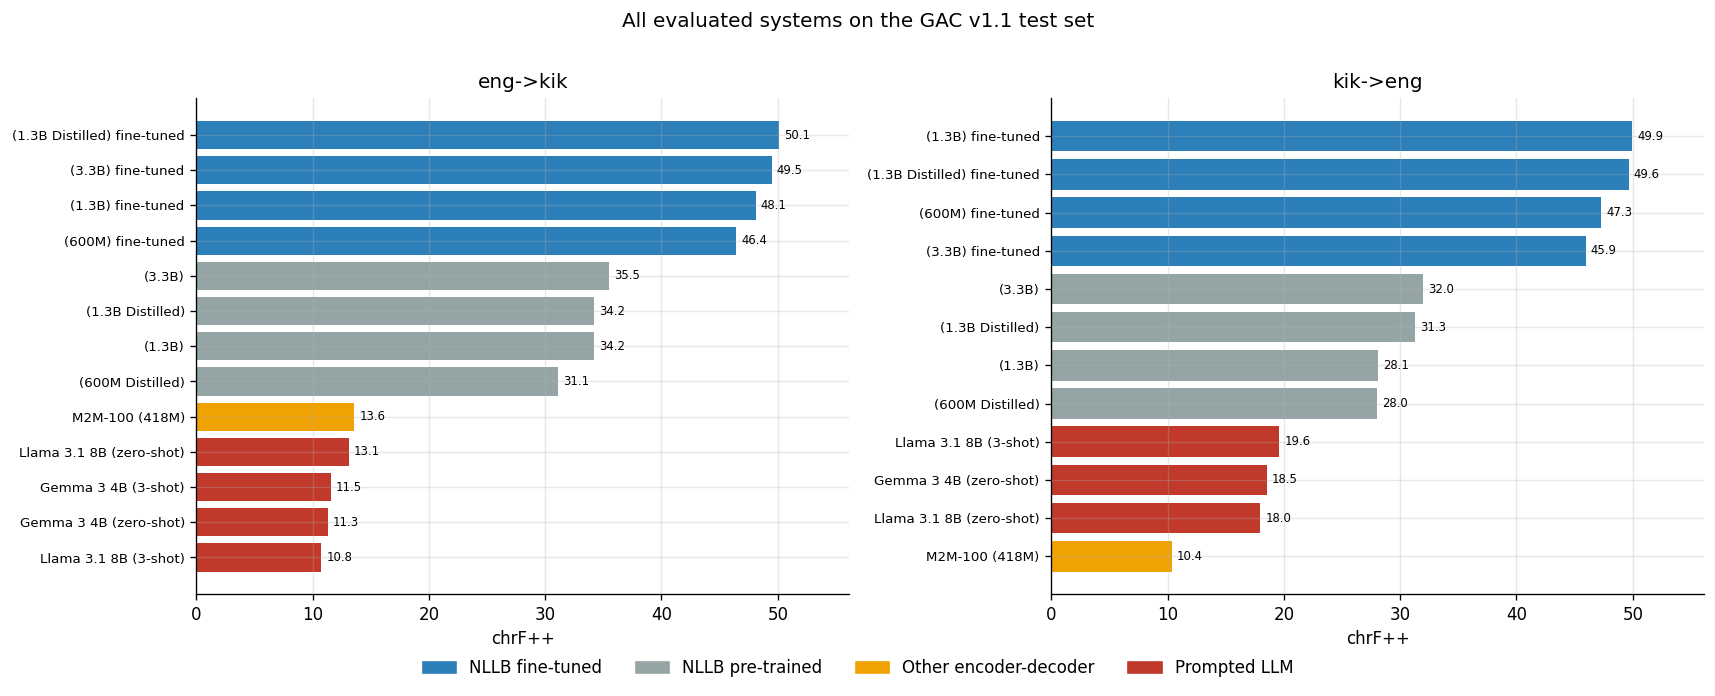

In [14]:
# Figure 7 — full leaderboard by category
fig, axes = plt.subplots(1, len(DIRECTIONS), figsize=(7.2 * len(DIRECTIONS), 5.4), squeeze=False)
for ax, direction in zip(axes[0], DIRECTIONS):
    sub = (LANDSCAPE[LANDSCAPE["Direction"] == direction]
           .sort_values("chrF++", ascending=True))
    colours = [CATEGORY_COLOUR[c] for c in sub["Category"]]
    ax.barh(range(len(sub)), sub["chrF++"], color=colours)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels([s.replace("NLLB-200 ", "").replace(" Instruct", "")
                        for s in sub["System"]], fontsize=8)
    for i, v in enumerate(sub["chrF++"]):
        ax.annotate(f"{v:.1f}", (v, i), xytext=(3, 0), textcoords="offset points",
                    va="center", fontsize=7)
    ax.set_xlabel("chrF++")
    ax.set_title(direction)
    ax.set_xlim(0, max(LANDSCAPE["chrF++"]) * 1.12)

handles = [plt.Rectangle((0, 0), 1, 1, color=CATEGORY_COLOUR[c]) for c in CATEGORY_ORDER]
fig.legend(handles, CATEGORY_ORDER, loc="lower center", ncol=4,
           frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("All evaluated systems on the GAC v1.1 test set", y=1.01)
fig.tight_layout()
fig.savefig(FIGDIR / "fig7_full_leaderboard.png", bbox_inches="tight")
plt.show()

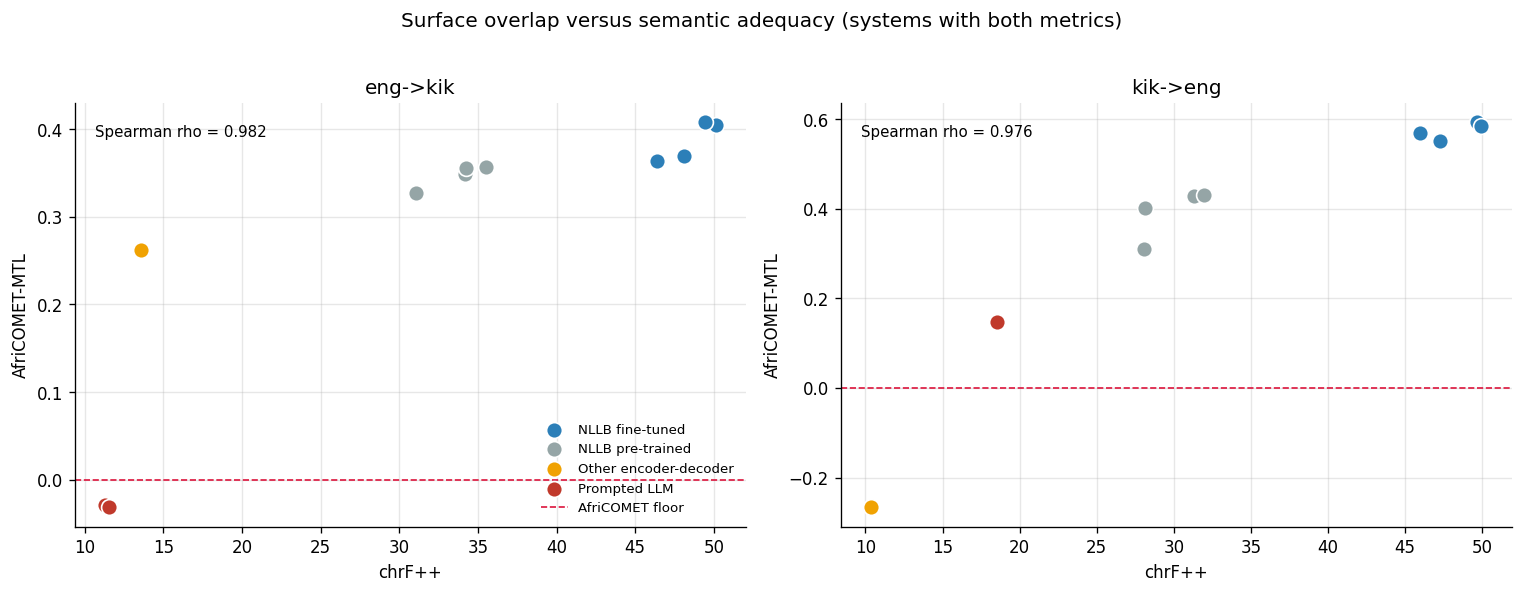

In [15]:
# Figure 8 — chrF++ against AfriCOMET-MTL across the landscape
fig, axes = plt.subplots(1, len(DIRECTIONS), figsize=(6.4 * len(DIRECTIONS), 4.8), squeeze=False)
for ax, direction in zip(axes[0], DIRECTIONS):
    sub = LANDSCAPE[(LANDSCAPE["Direction"] == direction) & LANDSCAPE["AfriCOMET"].notna()]
    for cat in CATEGORY_ORDER:
        s = sub[sub["Category"] == cat]
        if not len(s):
            continue
        ax.scatter(s["chrF++"], s["AfriCOMET"], s=90, label=cat,
                   color=CATEGORY_COLOUR[cat], edgecolor="white", zorder=3)
    ax.axhline(0, color="crimson", ls="--", lw=1,
               label="AfriCOMET floor" if direction == DIRECTIONS[0] else None)
    ax.set_xlabel("chrF++"); ax.set_ylabel("AfriCOMET-MTL")
    ax.set_title(direction)
    if len(sub) > 2:
        rho = stats.spearmanr(sub["chrF++"], sub["AfriCOMET"]).statistic
        ax.annotate(f"Spearman rho = {rho:.3f}", (0.03, 0.95), xycoords="axes fraction",
                    fontsize=9, va="top")
axes[0][0].legend(frameon=False, fontsize=8, loc="lower right")
fig.suptitle("Surface overlap versus semantic adequacy (systems with both metrics)", y=1.02)
fig.tight_layout()
fig.savefig(FIGDIR / "fig8_chrf_vs_africomet.png", bbox_inches="tight")
plt.show()

**Figures 7 and 8.** Figure 7 makes the stratification visible: the blue (fine-tuned)
band sits clearly above the grey (pre-trained) band, which in turn sits well above the
red (prompted LLM) and orange (M2M-100) systems. The categories barely overlap in
eng→kik, and the ordering is largely preserved in kik→eng despite the LLMs' improvement.

Figure 8 plots surface overlap against semantic adequacy for systems where both metrics
exist. The two agree strongly (high positive Spearman ρ), and the categories form
distinct clusters rather than lying on a continuum — the fine-tuned systems occupy the
upper right, while the prompted LLMs sit near or below the AfriCOMET floor of zero
despite non-trivial chrF++. That combination, high-ish surface overlap with negligible
adequacy, is the quantitative signature of fluent-looking output that does not carry the
source meaning, and it is precisely why the benchmark recommends reporting chrF++ and
AfriCOMET together rather than either alone.

## 12. Figures

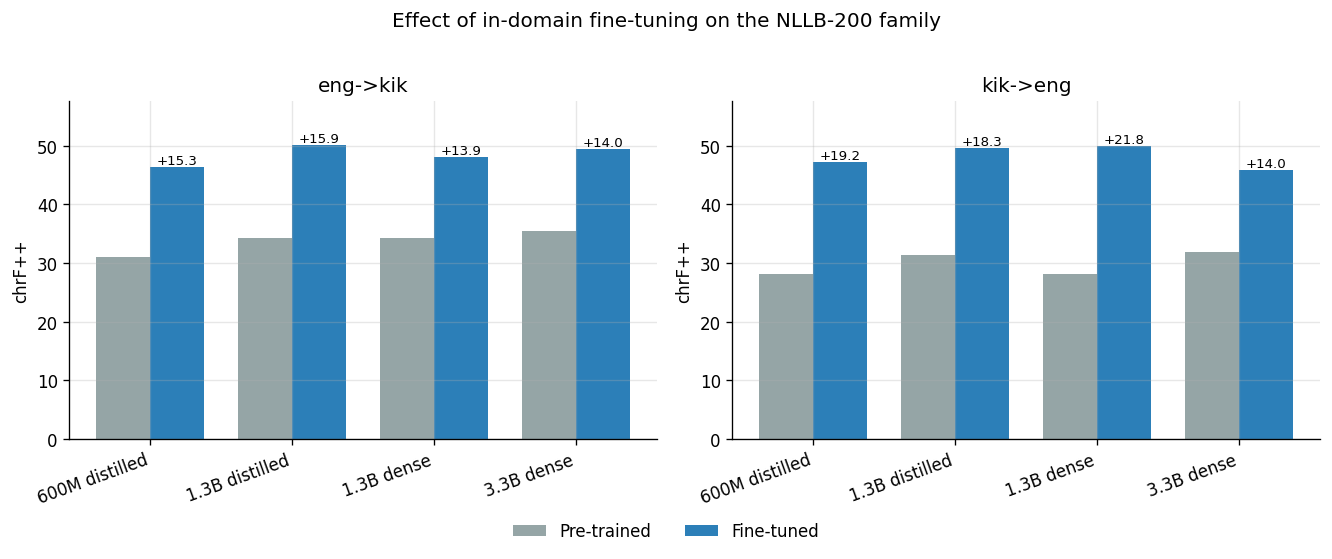

In [16]:
# Figure 1 — baseline vs fine-tuned chrF++ by checkpoint and direction
avail = [d for d in DIRECTIONS if len(SCALING[SCALING["Direction"] == d]) > 0]
if avail:
    fig, axes = plt.subplots(1, len(avail), figsize=(5.6 * len(avail), 4.2), squeeze=False)
    ymax = max(SCALING["Fine-tuned chrF++"].max(), SCALING["Baseline chrF++"].max())
    for ax, d in zip(axes[0], avail):
        sub = SCALING[SCALING["Direction"] == d]
        x = np.arange(len(sub)); w = 0.38
        ax.bar(x - w / 2, sub["Baseline chrF++"], w, label="Pre-trained", color="#95a5a6")
        ax.bar(x + w / 2, sub["Fine-tuned chrF++"], w, label="Fine-tuned", color="#2c7fb8")
        for i, (b, f) in enumerate(zip(sub["Baseline chrF++"], sub["Fine-tuned chrF++"])):
            ax.annotate(f"+{f - b:.1f}", (i + w / 2, f), ha="center", va="bottom", fontsize=8)
        ax.set_xticks(x); ax.set_xticklabels(sub["Checkpoint"], rotation=20, ha="right")
        ax.set_ylabel("chrF++"); ax.set_title(d)
        # Headroom so the +Δ annotations never collide with the frame
        ax.set_ylim(0, ymax * 1.15)

    # A single figure-level legend below the panels keeps it clear of the bars
    handles, labels_ = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", ncol=2, frameon=False,
               bbox_to_anchor=(0.5, -0.06))
    fig.suptitle("Effect of in-domain fine-tuning on the NLLB-200 family", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGDIR / "fig1_finetuning_gains.png", bbox_inches="tight")
    plt.show()


**Figure 1.** The gap between the grey (pre-trained) and blue (fine-tuned) bars is
substantially larger than any difference *within* either group. In other words, the
choice of whether to fine-tune matters far more than the choice of checkpoint — the
practical message for anyone building a Gĩkũyũ MT system on a limited budget.

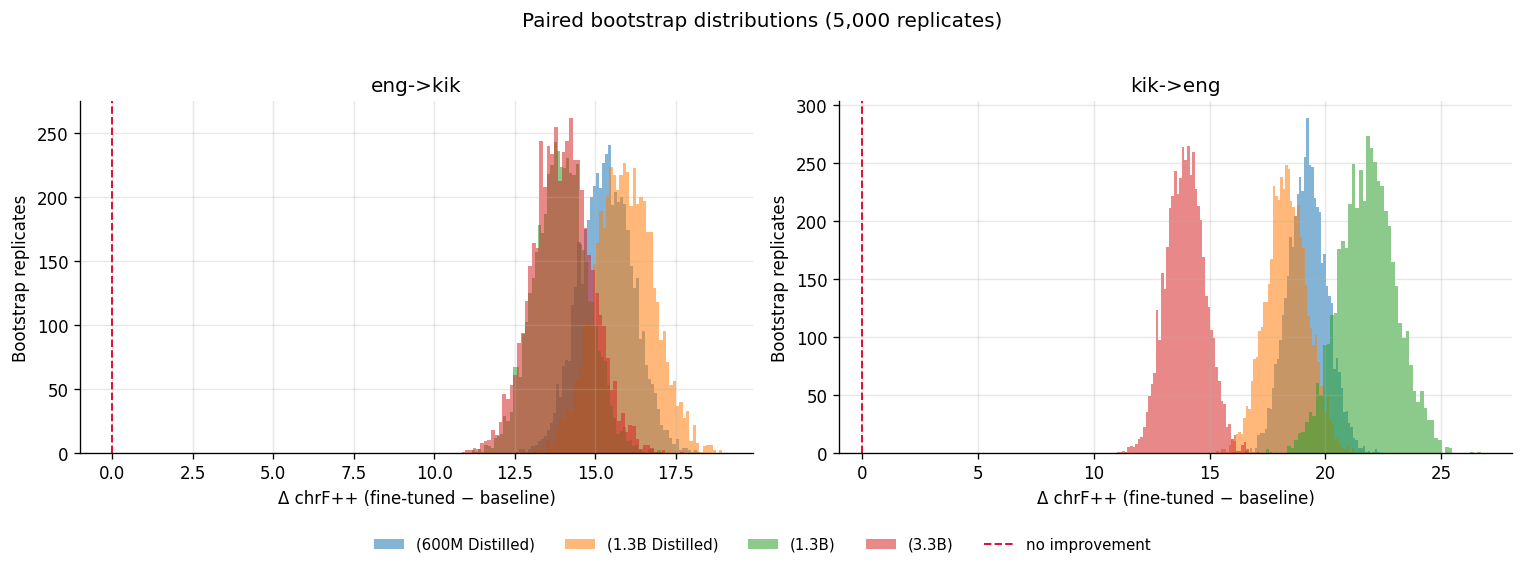

Distributions lying entirely to the right of zero indicate an improvement
that is robust to resampling of the test set.


In [17]:
# Figure 2 — bootstrap distributions of the chrF++ improvement
chrf_keys = [k for k in boot_store if k[2] == "chrf"]
if chrf_keys:
    fig, axes = plt.subplots(1, len(DIRECTIONS), figsize=(6.4 * len(DIRECTIONS), 4.2), squeeze=False)
    for ax, d in zip(axes[0], DIRECTIONS):
        # Filter on the metric as well as the direction: boot_store also holds
        # BLEU replicates, which must not be overlaid on a chrF++ axis.
        for (dd, base, metric), res in boot_store.items():
            if dd != d or metric != "chrf":
                continue
            ax.hist(res["deltas"], bins=60, alpha=0.55,
                    label=base.replace("NLLB-200 ", ""))
        ax.axvline(0, color="crimson", ls="--", lw=1.2, label="no improvement")
        ax.set_xlabel("Δ chrF++ (fine-tuned − baseline)")
        ax.set_ylabel("Bootstrap replicates"); ax.set_title(d)
        ax.set_xlim(left=-1)          # keep the zero reference line visible

    handles, labels_ = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels_, loc="lower center", ncol=5, frameon=False,
               bbox_to_anchor=(0.5, -0.08), fontsize=9)
    fig.suptitle(f"Paired bootstrap distributions ({N_BOOTSTRAP:,} replicates)", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGDIR / "fig2_bootstrap.png", bbox_inches="tight")
    plt.show()
    print("Distributions lying entirely to the right of zero indicate an improvement")
    print("that is robust to resampling of the test set.")


**Figure 2.** Every bootstrap distribution lies entirely to the right of the dashed
zero line, which is the visual counterpart of the p-values in Section 4: across 5,000
resamplings of the test set, there is no plausible sample in which fine-tuning fails to
help. The spread of each distribution indicates the precision of the estimate, and the
wider distributions in kik→eng reflect the greater variability of that direction.

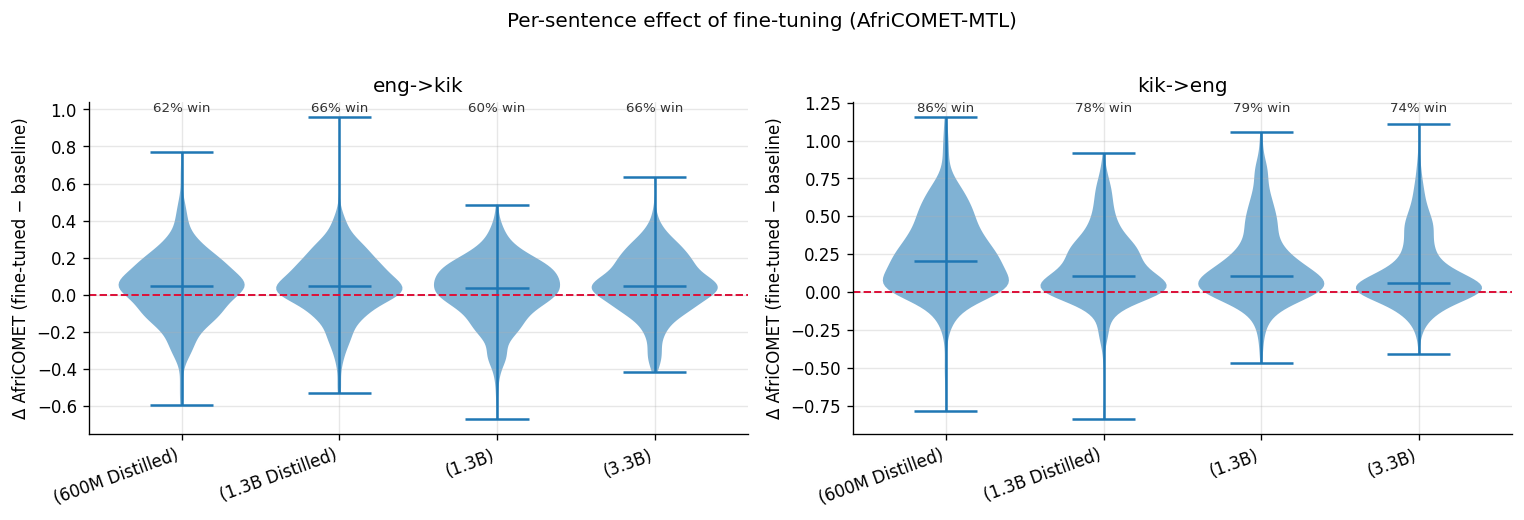

In [18]:
# Figure 3 — sentence-level AfriCOMET improvement distributions
panels = [(d, ft, base) for d in DIRECTIONS for ft, base in PAIRS.items()
          if sentence_africomet(d, ft) is not None and sentence_africomet(d, base) is not None]
if panels:
    fig, axes = plt.subplots(1, len(DIRECTIONS), figsize=(6.4 * len(DIRECTIONS), 4.2), squeeze=False)
    for ax, d in zip(axes[0], DIRECTIONS):
        data, panel_labels = [], []
        for ft, base in PAIRS.items():
            a, b = sentence_africomet(d, ft), sentence_africomet(d, base)
            if a is None or b is None:
                continue
            data.append(a - b)
            panel_labels.append(base.replace("NLLB-200 ", ""))
        if not data:
            continue
        parts = ax.violinplot(data, showmedians=True, widths=0.8)
        for pc in parts["bodies"]:
            pc.set_facecolor("#2c7fb8"); pc.set_alpha(0.6)
        ax.axhline(0, color="crimson", ls="--", lw=1.2)
        ax.set_xticks(range(1, len(panel_labels) + 1))
        ax.set_xticklabels(panel_labels, rotation=20, ha="right")
        ax.set_ylabel("Δ AfriCOMET (fine-tuned − baseline)")
        ax.set_title(d)
        for i, arr in enumerate(data, start=1):
            ax.annotate(f"{(arr > 0).mean():.0%} win", (i, ax.get_ylim()[1]),
                        ha="center", va="top", fontsize=8, color="#333333")
    fig.suptitle("Per-sentence effect of fine-tuning (AfriCOMET-MTL)", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGDIR / "fig3_sentence_level.png", bbox_inches="tight")
    plt.show()

**Figure 3.** The violins show that the improvement is a distributional shift, not an
artefact of a few large wins. The kik→eng panel sits clearly above zero with win rates
of 74–86%, whereas the eng→kik panel straddles zero more closely (60–66% win rates)
with a visible mass of sentences that fine-tuning does not improve. This is the same
directional asymmetry identified in Sections 3 and 5, shown here at the level of
individual sentences.

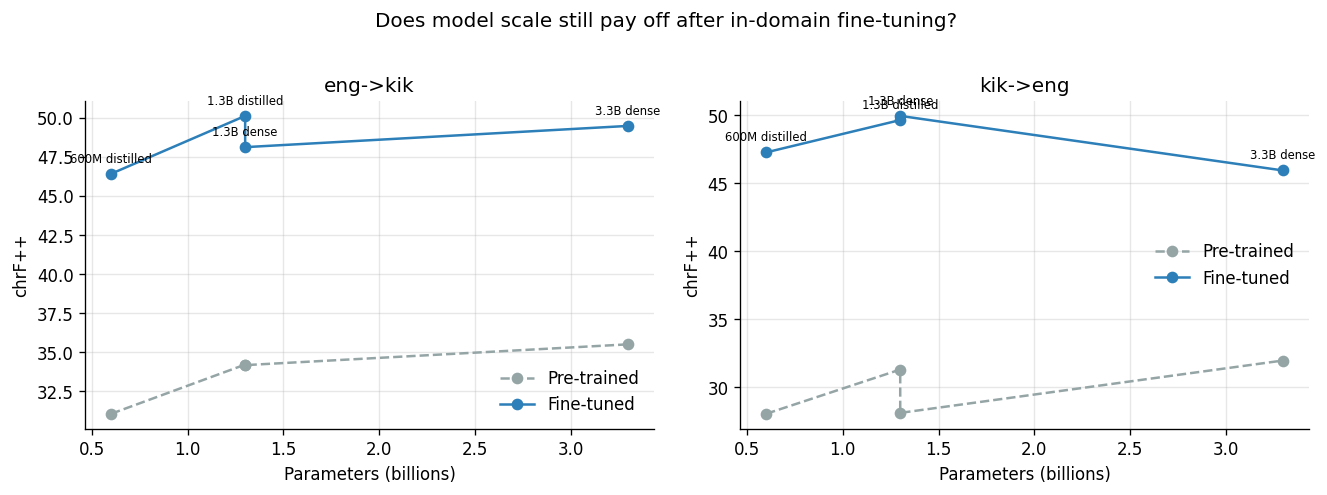

In [19]:
# Figure 4 — scaling curves, baseline vs fine-tuned
if len(SCALING):
    fig, axes = plt.subplots(1, len(DIRECTIONS), figsize=(5.6 * len(DIRECTIONS), 4), squeeze=False)
    for ax, d in zip(axes[0], DIRECTIONS):
        sub = SCALING[SCALING["Direction"] == d].sort_values("Params (B)")
        if not len(sub):
            continue
        ax.plot(sub["Params (B)"], sub["Baseline chrF++"], "o--",
                color="#95a5a6", label="Pre-trained")
        ax.plot(sub["Params (B)"], sub["Fine-tuned chrF++"], "o-",
                color="#2c7fb8", label="Fine-tuned")
        for _, r in sub.iterrows():
            ax.annotate(r["Checkpoint"], (r["Params (B)"], r["Fine-tuned chrF++"]),
                        textcoords="offset points", xytext=(0, 7), ha="center", fontsize=7)
        ax.set_xlabel("Parameters (billions)"); ax.set_ylabel("chrF++")
        ax.set_title(d); ax.legend(frameon=False)
    fig.suptitle("Does model scale still pay off after in-domain fine-tuning?", y=1.02)
    fig.tight_layout()
    fig.savefig(FIGDIR / "fig4_scaling.png", bbox_inches="tight")
    plt.show()

**Figure 4.** The two lines tell opposing stories. The grey (pre-trained) line rises
monotonically with parameter count, reproducing the benchmark's scaling finding. The
blue (fine-tuned) line is essentially flat in eng→kik and *declines* at 3.3B in
kik→eng. In-domain adaptation largely substitutes for scale on this task, so the
additional parameters of the 3.3B are not repaid once the smaller models have seen
domain data.

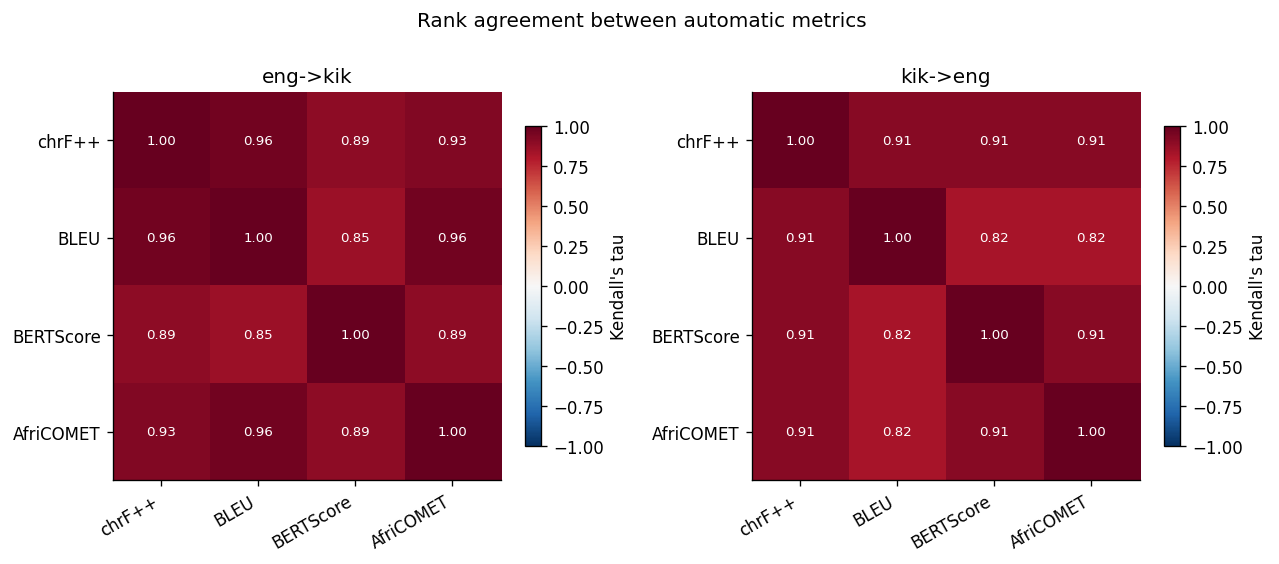

In [20]:
METRIC_LABELS = {"chrf_pp": "chrF++", "bleu": "BLEU",
                 "bertscore_f1": "BERTScore", "africomet_mtl": "AfriCOMET"}

# Figure 5 — metric agreement (Kendall's tau) and BERTScore behaviour
fig, axes = plt.subplots(1, len(DIRECTIONS), figsize=(5.4 * len(DIRECTIONS), 4.4), squeeze=False)
for ax, d in zip(axes[0], DIRECTIONS):
    block = {n: m for n, m in METRICS.get(d, {}).items()
             if m.get("chrf_pp", 0) > 0 and m.get("africomet_mtl") is not None}
    if len(block) < 4:
        ax.axis("off"); continue
    df = pd.DataFrame(block).T[metric_cols].astype(float).rename(columns=METRIC_LABELS)
    tau = np.eye(len(df.columns))
    for i, ci in enumerate(df.columns):
        for j, cj in enumerate(df.columns):
            if i != j:
                tau[i, j] = stats.kendalltau(df[ci], df[cj]).statistic
    im = ax.imshow(tau, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(df.columns))); ax.set_xticklabels(df.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(df.columns))); ax.set_yticklabels(df.columns)
    for i in range(len(df.columns)):
        for j in range(len(df.columns)):
            ax.text(j, i, f"{tau[i, j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if abs(tau[i, j]) > 0.6 else "black")
    ax.set_title(d); ax.grid(False)
    fig.colorbar(im, ax=ax, shrink=0.8, label="Kendall's tau")
fig.suptitle("Rank agreement between automatic metrics", y=1.03)
fig.tight_layout()
fig.savefig(FIGDIR / "fig5_metric_agreement.png", bbox_inches="tight")
plt.show()

**Figure 5.** The heatmaps are uniformly warm, confirming that all four metrics rank
these systems similarly. This is expected given a homogeneous pool of NLLB variants and
should not be read as a general endorsement of metric interchangeability: the benchmark
showed that agreement breaks down precisely when degenerate systems are included.

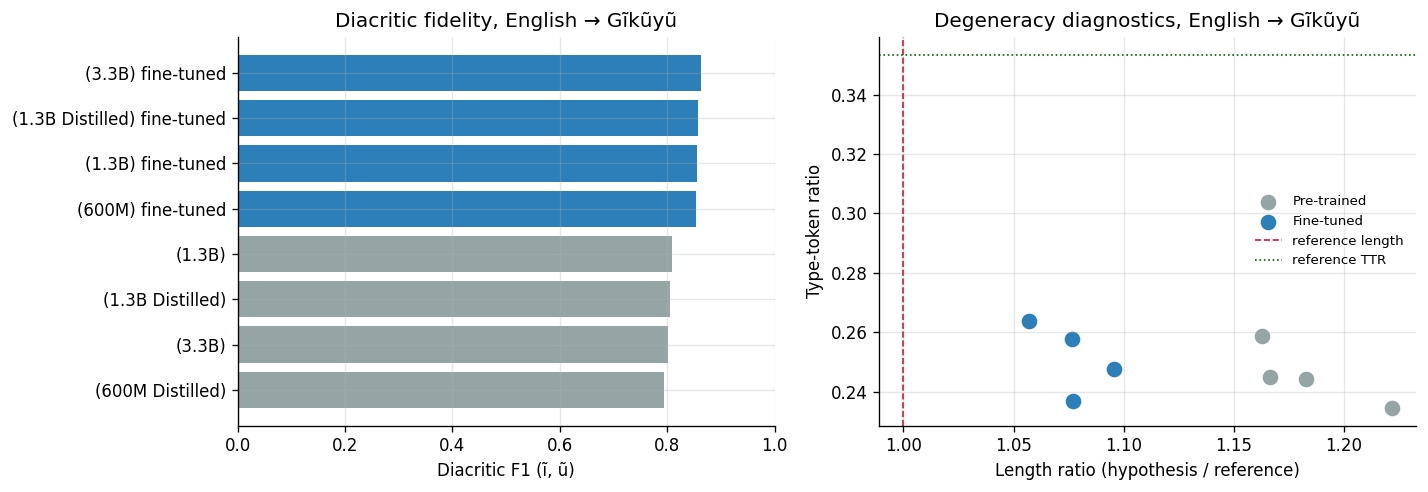

In [21]:
# Figure 6 — diacritic fidelity and output-length diagnostics (eng->kik)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

if len(DIA):
    dia = DIA.sort_values("F1")
    colours = ["#2c7fb8" if t == "Fine-tuned" else "#95a5a6" for t in dia["Type"]]
    axes[0].barh(dia["System"].str.replace("NLLB-200 ", ""), dia["F1"], color=colours)
    axes[0].set_xlabel("Diacritic F1 (ĩ, ũ)")
    axes[0].set_title("Diacritic fidelity, English → Gĩkũyũ")
    axes[0].set_xlim(0, 1)

sub = LEN[LEN["Direction"] == "eng->kik"]
if len(sub):
    for typ, colour in [("Base", "#95a5a6"), ("FT", "#2c7fb8")]:
        s = sub[sub["Type"] == typ]
        axes[1].scatter(s["Len ratio"], s["TTR"], s=70, color=colour,
                        label="Fine-tuned" if typ == "FT" else "Pre-trained")
    if len(sub):
        axes[1].axvline(1.0, color="crimson", ls="--", lw=1, label="reference length")
        axes[1].axhline(sub["Ref TTR"].iloc[0], color="darkgreen", ls=":", lw=1,
                        label="reference TTR")
    axes[1].set_xlabel("Length ratio (hypothesis / reference)")
    axes[1].set_ylabel("Type-token ratio")
    axes[1].set_title("Degeneracy diagnostics, English → Gĩkũyũ")
    axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout()
fig.savefig(FIGDIR / "fig6_diacritics_length.png", bbox_inches="tight")
plt.show()

**Figure 6.** The left panel separates cleanly into fine-tuned systems (blue, F1 ≈ 0.85)
and baselines (grey, F1 ≈ 0.80). The right panel is the more diagnostic view: the
pre-trained systems sit to the right of the reference-length line with depressed
type-token ratios, while the fine-tuned systems cluster near a length ratio of 1.0 with
TTRs closer to the reference. The isolated point at the far right is the 1.3B dense
kik→eng baseline discussed in Section 10.

## 13. LaTeX export

Publication-ready tables written to `results/figures_finetuning/`.

In [22]:
exports = {
    "table_results_eng2kik.tex": (TABLES.get("eng->kik"), "Benchmark results, English to Gĩkũyũ."),
    "table_results_kik2eng.tex": (TABLES.get("kik->eng"), "Benchmark results, Gĩkũyũ to English."),
    "table_gains.tex": (GAINS, "Improvement from in-domain fine-tuning."),
    "table_bootstrap.tex": (BOOT if len(BOOT) else None, "Paired bootstrap significance tests."),
    "table_wilcoxon.tex": (WILCOXON if len(WILCOXON) else None, "Wilcoxon signed-rank tests on sentence-level AfriCOMET-MTL."),
}

for fname, (df, caption) in exports.items():
    if df is None or not len(df):
        continue
    (FIGDIR / fname).write_text(
        df.to_latex(index=False, float_format="%.2f", caption=caption,
                    label=f"tab:{fname.replace('table_', '').replace('.tex', '')}",
                    escape=False)
    )
    print(f"wrote {FIGDIR / fname}")

print(f"\nFigures and tables: {FIGDIR}")

wrote results/figures_finetuning/table_results_eng2kik.tex
wrote results/figures_finetuning/table_results_kik2eng.tex
wrote results/figures_finetuning/table_gains.tex
wrote results/figures_finetuning/table_bootstrap.tex
wrote results/figures_finetuning/table_wilcoxon.tex

Figures and tables: results/figures_finetuning


## 14. Summary

Automatically generated summary of the findings above, for transfer into the manuscript.

In [23]:
print("=" * 78)
print("SUMMARY OF FINDINGS")
print("=" * 78)

print(f"\nTest set: GAC v1.1 held-out split, n = {n_sent}")
print(f"Bootstrap replicates: {N_BOOTSTRAP:,}; family-wise correction: Holm-Bonferroni")

print("\nRQ1 - Effect of fine-tuning")
for d in DIRECTIONS:
    sub = GAINS[GAINS["Direction"] == d]
    if len(sub):
        print(f"  {d}: mean chrF++ {sub['Δ chrF++'].mean():+.2f} "
              f"(range {sub['Δ chrF++'].min():+.2f} to {sub['Δ chrF++'].max():+.2f}), "
              f"mean AfriCOMET {sub['Δ AfriCOMET'].mean():+.3f}")
if len(BOOT):
    n_sig = int(BOOT["Significant (Holm)"].sum())
    print(f"  Bootstrap: {n_sig}/{len(BOOT)} comparisons significant after correction")
if len(WILCOXON):
    n_sig = int(WILCOXON["Significant (Holm)"].sum())
    print(f"  Wilcoxon (AfriCOMET): {n_sig}/{len(WILCOXON)} significant; "
          f"mean win rate {WILCOXON['Win rate'].mean():.1%}")

print("\nRQ2 - Scaling after fine-tuning")
for d in DIRECTIONS:
    sub = SCALING[SCALING["Direction"] == d]
    if len(sub) >= 2:
        sb = sub["Baseline chrF++"].max() - sub["Baseline chrF++"].min()
        sf = sub["Fine-tuned chrF++"].max() - sub["Fine-tuned chrF++"].min()
        best = sub.loc[sub["Fine-tuned chrF++"].idxmax(), "Checkpoint"]
        print(f"  {d}: spread {sb:.2f} -> {sf:.2f}; best fine-tuned = {best}")

print("\nRQ4 - Metric behaviour")
print("  See Section 8; chrF++ and AfriCOMET-MTL should be reported together.")

print("\nCaveats")
print("  - Single agricultural domain; no claim is made for other registers.")
print("  - Automatic metrics only; native-speaker assessment is the definitive check.")
print("  - AfriCOMET is not pre-trained on Gĩkũyũ, so it relies on cross-lingual transfer.")
print("=" * 78)

SUMMARY OF FINDINGS

Test set: GAC v1.1 held-out split, n = {'eng->kik': 450, 'kik->eng': 450}
Bootstrap replicates: 5,000; family-wise correction: Holm-Bonferroni

RQ1 - Effect of fine-tuning
  eng->kik: mean chrF++ +14.78 (range +13.93 to +15.89), mean AfriCOMET +0.039
  kik->eng: mean chrF++ +18.34 (range +13.97 to +21.84), mean AfriCOMET +0.181
  Bootstrap: 16/16 comparisons significant after correction
  Wilcoxon (AfriCOMET): 8/8 significant; mean win rate 71.3%

RQ2 - Scaling after fine-tuning
  eng->kik: spread 4.44 -> 3.70; best fine-tuned = 1.3B distilled
  kik->eng: spread 3.92 -> 4.01; best fine-tuned = 1.3B dense

RQ4 - Metric behaviour
  See Section 8; chrF++ and AfriCOMET-MTL should be reported together.

Caveats
  - Single agricultural domain; no claim is made for other registers.
  - Automatic metrics only; native-speaker assessment is the definitive check.
  - AfriCOMET is not pre-trained on Gĩkũyũ, so it relies on cross-lingual transfer.
